In [59]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.abspath('../../'))
from slava.modules.data_loader import DataLoader

def load_and_prepare_data():
    """
    Загружает и подготавливает данные: нормализует вложенные JSON-данные,
    очищает от лишних колонок и объединяет все в один DataFrame.
    """
    # Загрузка данных
    data_loader = DataLoader()
    data = data_loader.load_data()

    # Валидация формата данных
    data_loader.validate_format(data)

    # Нормализация вложенных колонок JSON
    inputs_expanded = pd.json_normalize(data['inputs'])
    outputs_expanded = pd.json_normalize(data['outputs'])
    meta_expanded = pd.json_normalize(data['meta'])

    # Убираем старые колонки и объединяем все данные
    data_expanded = data.drop(columns=['inputs', 'outputs', 'meta'])
    data = pd.concat([data_expanded, inputs_expanded, outputs_expanded, meta_expanded], axis=1)

    return data

def display_basic_info(data):
    """
    Выводит базовую информацию о DataFrame: размер, типы данных и количество пропусков.
    """
    print(f"Data Shape: {data.shape}")
    print("\nData Info:")
    print(data.info())
    print("\nMissing Values:")
    print(data.isnull().sum())
    print("\nDescriptive Statistics:")
    print(data.describe())

def analyze_subjects_and_types(data):
    """
    Проводит анализ распределения вопросов по предмету и типу.
    Строит соответствующие графики.
    """
    print("\nSubject Distribution:")
    print(data['subject'].value_counts())

    print("\nType Distribution:")
    print(data['type'].value_counts())

    # Графики распределения
    plt.figure(figsize=(10, 6))
    sns.countplot(data=data, x='subject', order=data['subject'].value_counts().index)
    plt.title('Distribution of Questions by Subject')
    plt.xticks(rotation=45)
    plt.show()

    plt.figure(figsize=(10, 6))
    sns.countplot(data=data, x='type', order=data['type'].value_counts().index)
    plt.title('Distribution of Questions by Type')
    plt.xticks(rotation=45)
    plt.show()

def analyze_text_lengths(data):
    """
    Анализирует длину инструкций и задач, строит гистограммы их распределения.
    """
    # Создание новых признаков для длинны
    data['instruction_length'] = data['instruction'].apply(len)
    data['task_length'] = data['task'].apply(len)

    print("\nInstruction and Task Lengths Description:")
    print(data[['instruction_length', 'task_length']].describe())

    # Гистограммы для длины инструкций и задач
    plt.figure(figsize=(10, 6))
    sns.histplot(data['instruction_length'], kde=True, color='blue', bins=20)
    plt.title('Distribution of Instruction Lengths')
    plt.show()

    plt.figure(figsize=(10, 6))
    sns.histplot(data['task_length'], kde=True, color='green', bins=20)
    plt.title('Distribution of Task Lengths')
    plt.show()

def analyze_provoc_score(data):
    """
    Анализирует распределение оценок провокативности и строит график.
    """
    print("\nProvocativeness Score Distribution:")
    print(data['provoc_score'].value_counts())

    plt.figure(figsize=(10, 6))
    sns.countplot(data=data, x='provoc_score', order=data['provoc_score'].value_counts().index)
    plt.title('Distribution of Provocativeness Score')
    plt.show()

def analyze_open_and_closed_questions(data):
    """
    Анализирует распределение открытых и закрытых вопросов по типу.
    Строит график и выводит результаты.
    """
    data['is_open_question'] = data['type'].apply(lambda x: 1 if x == 'открытый ответ' else 0)
    
    # Распределение открытых и закрытых вопросов
    open_closed_counts = data['is_open_question'].value_counts()
    print(f"Распределение открытых и закрытых вопросов:\n{open_closed_counts}")
    
    plt.figure(figsize=(10, 6))
    sns.countplot(data=data, x='is_open_question')
    plt.title('Distribution of Open and Not Open Questions')
    plt.xticks([0, 1], ['Closed', 'Open'])
    plt.show()

def analyze_provoc_score_by_type(data):
    """
    Анализирует провокативность в зависимости от типа вопроса.
    Строит график и выводит результаты.
    """
    provoc_score_by_type = data.groupby('type')['provoc_score'].value_counts().unstack().fillna(0)
    print(f"Провокативность по типу вопроса:\n{provoc_score_by_type}")
    
    plt.figure(figsize=(10, 6))
    sns.countplot(data=data, x='type', hue='provoc_score')
    plt.title('Provocativeness by Question Type')
    plt.xticks(rotation=45)
    plt.show()


# EDA Анализ

## Шаг 1: Загрузка и подготовка данных

На этом шаге данные были загружены и подготовлены для дальнейшего анализа:
- Произведена загрузка исходных данных с помощью класса `DataLoader`.
- Вложенные JSON-данные (в колонках `inputs`, `outputs`, `meta`) были нормализованы с использованием `pd.json_normalize`.
- Старые колонки были удалены, и все данные объединены в один DataFrame.



In [60]:
data = load_and_prepare_data()



In [67]:
data.head()

,id,instruction,task,text,options.option_1,options.option_2,options.option_3,options.option_4,options.option_5,options.option_6,...,options.option_8,options.option_9,subject,type,source,comment,provoc_score,instruction_length,task_length,is_open_question
0,5082,"Прочитайте приведённые далее задачу, текст и в...","В приведенном ряду найдите понятие, которое яв...","Выборы, референдум, форма демократии, сход гра...",None,None,None,None,None,None,...,None,None,Обществознание,открытый ответ,https://socege.sdamgia.ru/problem?id=11291,Д2,2,208,151,1
1,7195,Прочитайте приведённую далее задачу и выполнит...,В стране Y создан Центр изучения глобальных эк...,None,истощение запасов рыбы в мировом океане,озоновые дыры,глобальное перенаселение,распространение вируса СПИДа,старение населения в развитых странах,потепление климата,...,None,None,Обществознание,выбор ответа (мультивыбор),https://socege.sdamgia.ru/problem?id=69498,4,2,385,127,0
2,10280,"Прочитайте приведённые далее задачу, текст и в...",Выберите подходящее окончание для фразы.,Следствием проведения Крестьянской реформы 186...,предоставление помещикам права отдавать кресть...,прекращение деятельности народнических организ...,разрушение крестьянской общины,ускорение развития российской экономики,None,None,...,None,None,История,выбор ответа (один),https://hist-ege.sdamgia.ru/problem?id=3995,None,1,299,40,0
3,10126,"Прочитайте приведённые далее задачу, текст и в...",Выберите подходящее окончание для фразы.,Современниками были,Екатерина II и Екатерина Дашкова,Елизавета Петровна и А. А. Аракчеев,Анна Иоанновна и Иван Фёдоров,Екатерина I и М. М. Сперанский,None,None,...,None,None,История,выбор ответа (один),https://hist-ege.sdamgia.ru/problem?id=3670,None,1,299,40,0
4,9688,"Прочитайте приведённые далее задачу, текст и в...",Прочитайте отрывок из сочинения философа Н. Бе...,«Сейчас с трудом представляют себе атмосферу т...,None,None,None,None,None,None,...,None,None,История,открытый ответ,https://hist-ege.sdamgia.ru/problem?id=1227,None,2,208,119,1


In [69]:
data.iloc[0].tolist()

[5082,
 'Прочитайте приведённые далее задачу, текст и выполните по ним задание.\n Задача: {task}\n Текст: {text}\n Кратко сформулируйте и запишите ответ на задание (слово, словосочетание, одно или несколько предложений).',
 'В приведенном ряду найдите понятие, которое является обобщающим для всех остальных представленных понятий. Запишите в ответ это слово (словосочетание).',
 'Выборы, референдум, форма демократии, сход граждан, прямая демократия.',
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 'Обществознание',
 'открытый ответ',
 'https://socege.sdamgia.ru/problem?id=11291',
 'Д2',
 2,
 208,
 151,
 1]



## Шаг 2: Основная информация о данных

На этом шаге проведен первичный анализ данных:
- Проверены размеры данных (`shape`).
- Выведена информация о данных (`info`), включая типы данных.
- Рассмотрены пропущенные значения и базовые статистики для числовых данных с помощью `describe()`.

**Результат:**

- Размер данных.
- Количество пропущенных значений.
- Описание данных.



In [61]:
display_basic_info(data)


Data Shape: (2840, 18)

Data Info:
<class 'pandas.core.frame.DataFrame'>
Index: 2840 entries, 0 to 2839
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   id                2840 non-null   int64 
 1   instruction       2840 non-null   object
 2   task              2840 non-null   object
 3   text              967 non-null    object
 4   options.option_1  2549 non-null   object
 5   options.option_2  2549 non-null   object
 6   options.option_3  2548 non-null   object
 7   options.option_4  2391 non-null   object
 8   options.option_5  1168 non-null   object
 9   options.option_6  763 non-null    object
 10  options.option_7  35 non-null     object
 11  options.option_8  29 non-null     object
 12  options.option_9  25 non-null     object
 13  subject           2840 non-null   object
 14  type              2840 non-null   object
 15  source            2810 non-null   object
 16  comment           611 non-null

### Краткое саммари:

1. **Размер данных**: 
   - 2840 строк и 18 столбцов.

2. **Пропущенные значения**:
   - Столбцы с текстовыми данными (`text`, `options.option_*`, `comment`, `source`) имеют значительное количество пропусков.
   - Наибольшее количество пропусков в колонках с вариантами (`options.option_1` до `options.option_9`), а также в `comment` и `text`.
   - Поля `id`, `instruction`, `task`, `subject`, `type`, и `provoc_score` не содержат пропусков.

3. **Статистики**:
   - **`provoc_score`**: В основном значения 1 и 2, с минимальным значением 1 и максимальным 3. Среднее значение — 1.78.
   - **`id`**: Идентификаторы варьируются от 8 до 14198, с равномерным распределением по столбцу.

**Общий вывод**: 
- Данные содержат пропуски в важных для анализа столбцах, таких как `options` и `comment`.
- Данные по провокативности варьируются между 1 и 3, при этом большинство значений сосредоточено в пределах 1 и 2.



## Шаг 3: Анализ распределения по предметам и типам вопросов

Этот шаг включает в себя анализ распределения вопросов по категориям:
- Рассмотрены распределения по предметам (`subject`) и типам вопросов (`type`).
- Построены графики для визуализации распределения.

**Результат:**

- Распределение вопросов по предметам.
- Распределение вопросов по типам.



Subject Distribution:
subject
История           1114
Обществознание    1084
География          504
Политология        138
Name: count, dtype: int64

Type Distribution:
type
выбор ответа (один)            1204
выбор ответа (мультивыбор)      918
открытый ответ                  291
установление соответствия       233
указание последовательности     194
Name: count, dtype: int64


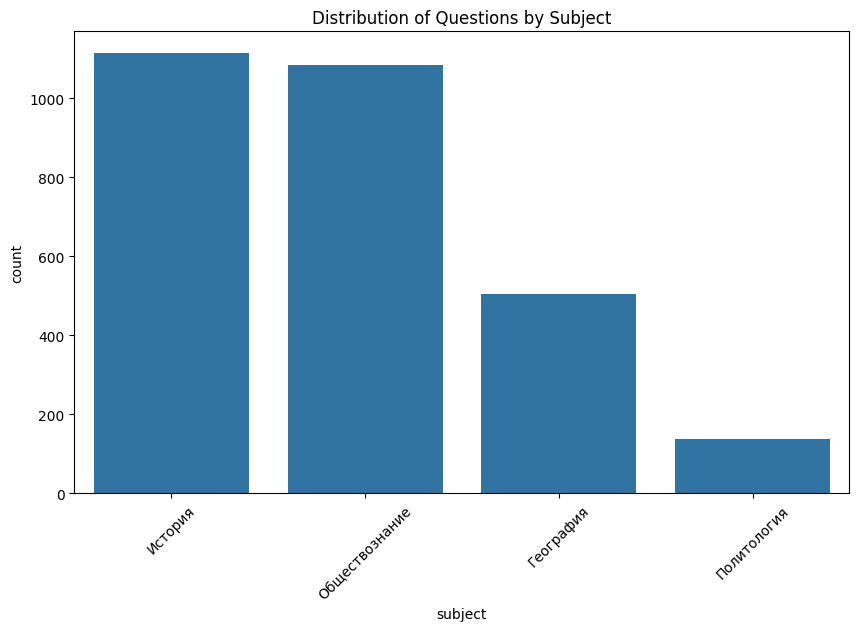

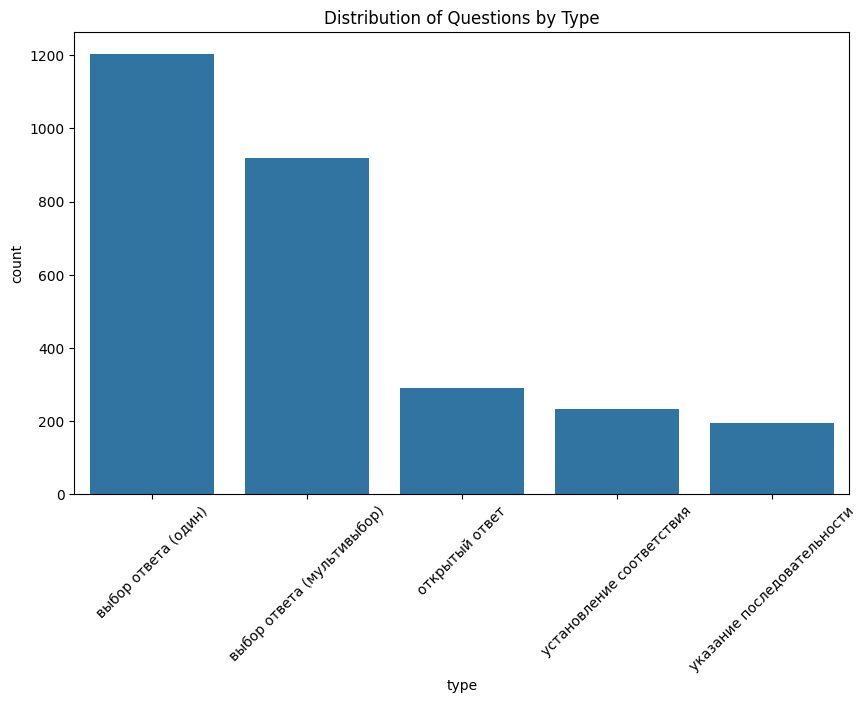

In [62]:
analyze_subjects_and_types(data)

### Краткое саммари:

1. **Распределение по предметам**:
   - **История**: 1114 вопросов
   - **Обществознание**: 1084 вопроса
   - **География**: 504 вопроса
   - **Политология**: 138 вопросов

2. **Распределение по типам вопросов**:
   - **Выбор ответа (один)**: 1204 вопроса
   - **Выбор ответа (мультивыбор)**: 918 вопросов
   - **Открытый ответ**: 291 вопрос
   - **Установление соответствия**: 233 вопроса
   - **Указание последовательности**: 194 вопроса

**Общий вывод**:
- Преобладающие предметы — **История** и **Обществознание**.
- Наиболее часто встречаемые типы вопросов — **выбор ответа (один)** и **мультивыбор**.



## Шаг 4: Анализ длины инструкций и задач

На этом шаге анализируется длина текстов инструкций и задач:
- Рассчитаны длины строк для инструкций и задач.
- Построены гистограммы для визуализации распределения длин.

**Результат:**

- Описание статистики для длины инструкций и задач.


Instruction and Task Lengths Description:
       instruction_length  task_length
count         2840.000000  2840.000000
mean           317.393662   103.867958
std             62.844866    78.163653
min            186.000000    15.000000
25%            277.000000    51.000000
50%            299.000000    77.000000
75%            385.000000   134.000000
max            503.000000   663.000000


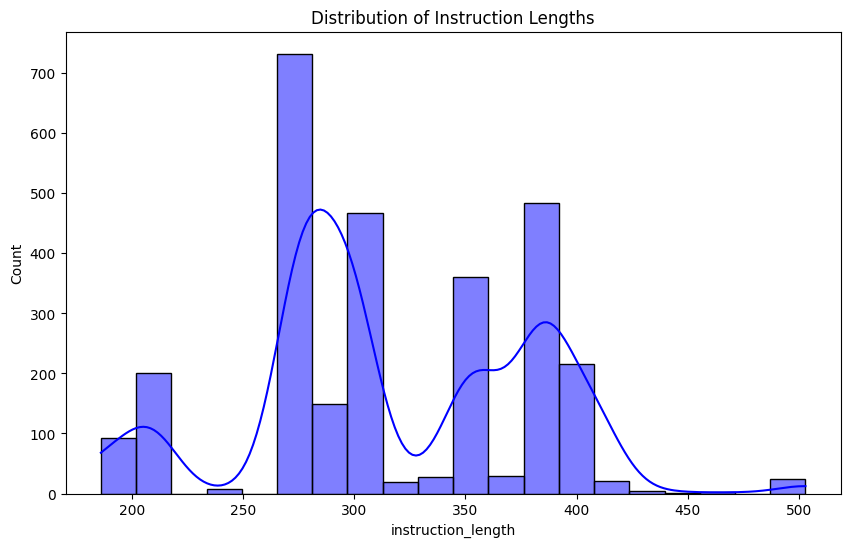

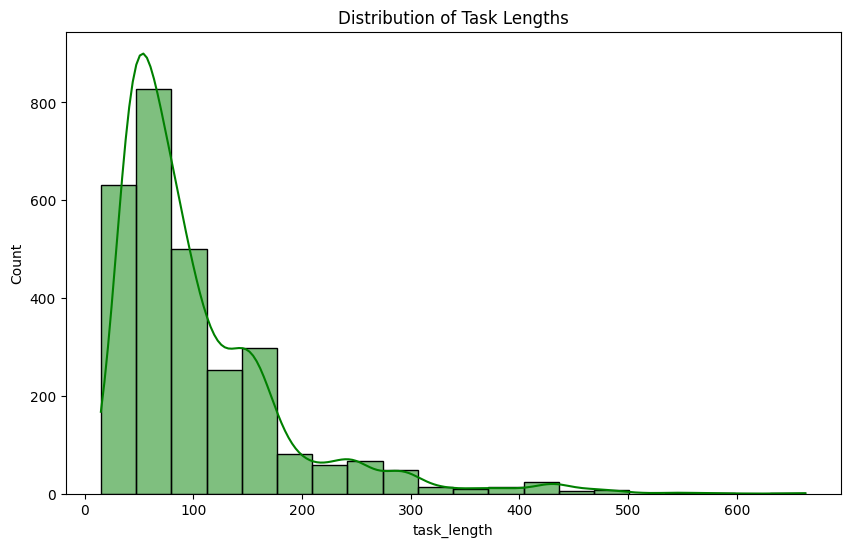

In [63]:
    analyze_text_lengths(data)


### Краткое саммари:

1. **Длина инструкций**:
   - Средняя длина: **317.39** символов.
   - Минимальная длина: **186** символов.
   - Максимальная длина: **503** символа.
   - Стандартное отклонение: **62.84** символа.

2. **Длина задач**:
   - Средняя длина: **103.87** символов.
   - Минимальная длина: **15** символов.
   - Максимальная длина: **663** символа.
   - Стандартное отклонение: **78.16** символов.

---

### Преобразование в токены:

Для оценки в **токенах** предполагаем, что каждый токен примерно равен 3 символам для русского текста (так как тексты, как правило, на русском языке).

- **Инструкция**:
  - Средняя длина: 317 символов → примерно **106 токенов**.
  - Минимальная длина: 186 символов → примерно **62 токена**.
  - Максимальная длина: 503 символа → примерно **168 токенов**.

- **Задача**:
  - Средняя длина: 104 символа → примерно **35 токенов**.
  - Минимальная длина: 15 символов → примерно **5 токенов**.
  - Максимальная длина: 663 символа → примерно **221 токен**.

Эти значения дают хорошее представление о среднем объеме текста в терминах токенов для обработки моделей NLP.



## Шаг 5: Анализ провокативности

На этом шаге анализируется распределение оценок провокативности (`provoc_score`):
- Рассмотрены возможные значения провокативности и их частота.
- Построен график для визуализации.

**Результат:**

- Распределение провокативности.



Provocativeness Score Distribution:
provoc_score
1    1316
2     834
3     690
Name: count, dtype: int64


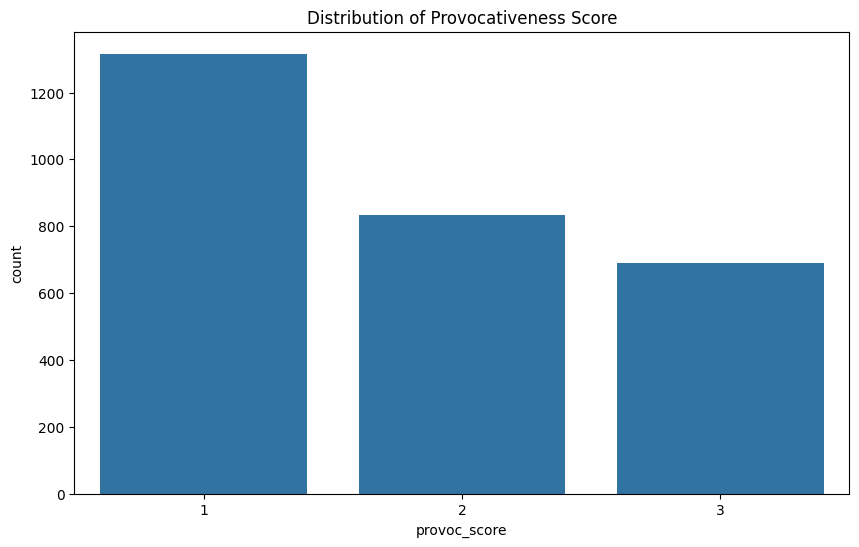

In [64]:
    analyze_provoc_score(data)


Большее количество вопросов с низким уровнем провокативности (1).
Средний и высокий уровни провокативности представлены менее равномерно, с меньшим количеством вопросов для каждого из них.



## Шаг 6: Анализ открытых и закрытых вопросов

Этот шаг включает в себя анализ типа вопросов:
- Рассмотрены вопросы с открытым и закрытым ответом.
- Построен график для отображения соотношения открытых и закрытых вопросов.

**Результат:**

- Количество открытых и закрытых вопросов.

Распределение открытых и закрытых вопросов:
is_open_question
0    2549
1     291
Name: count, dtype: int64


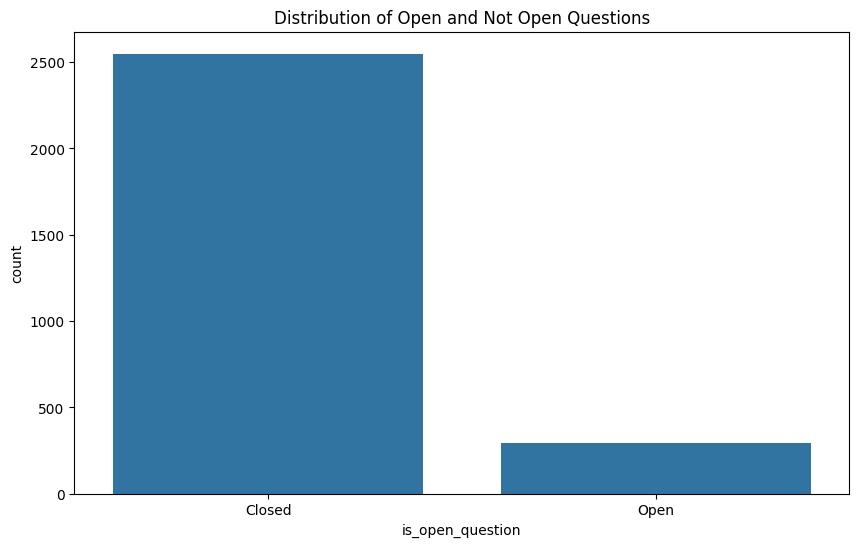

In [65]:
    analyze_open_and_closed_questions(data)




## Шаг 7: Анализ провокативности по типу вопроса

На этом шаге рассматривается, как провокативность связана с типом вопроса:
- Построен график для анализа провокативности в зависимости от типа вопроса.

**Результат:**

- Провокативность в зависимости от типа вопроса.



Провокативность по типу вопроса:
provoc_score                   1    2    3
type                                      
выбор ответа (мультивыбор)   395  221  302
выбор ответа (один)          595  429  180
открытый ответ               112   84   95
указание последовательности  176   13    5
установление соответствия     38   87  108


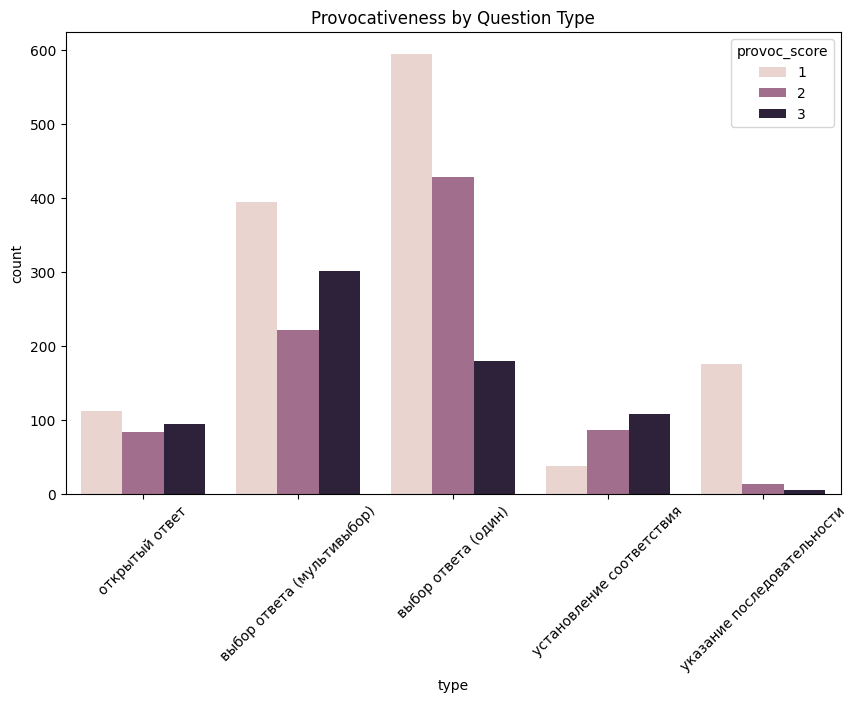

In [66]:
    analyze_provoc_score_by_type(data)


- Вопросы с **низкой провокативностью** (1) преобладают в типах "выбор ответа (один)" и "выбор ответа (мультивыбор)".
- В типах "установление соответствия" и "указание последовательности" значительно меньше вопросов с высокой провокативностью.
- **Средняя провокативность** более выражена в типах "выбор ответа (один)" и "выбор ответа (мультивыбор)", в то время как в других типах провокативность часто либо низкая, либо высокая.

### Общий вывод по всему датасету:

Датасет состоит из **2840 записей** с **18 колонками**, среди которых присутствуют как текстовые данные (например, инструкция и задача), так и метаинформация (например, тип вопроса, провокативность). В процессе анализа данных были получены следующие ключевые выводы:

1. **Недостающие значения**:
   - Некоторые столбцы содержат значительное количество пропущенных значений, особенно в таких колонках, как `text`, `options.option_5` и другие поля с опциями. Например, столбец `text` содержит пропущенные значения в **1873** случаях, что составляет примерно **66%** от всех записей.
   - Рекомендуется либо заполнить эти пропуски, если это возможно, либо удалить строки с отсутствующими значениями в критичных колонках, в зависимости от целей анализа.

2. **Типы вопросов**:
   - В датасете представлены различные типы вопросов, среди которых преобладают **выбор ответа (один)** и **выбор ответа (мультивыбор)**, что составляет более **60%** всех записей.
   - Редкими типами являются **установление соответствия** и **указание последовательности**, которые составляют небольшую долю данных.

3. **Предметы**:
   - Наибольшее количество вопросов связано с такими предметами, как **История** и **Обществознание**, которые составляют примерно **70%** всех данных. **География** и **Политология** представлены меньшими объемами, что может указывать на меньшую глубину охвата этих областей в датасете.

4. **Провокативность**:
   - Вопросы с **низкой провокативностью (1)** составляют наибольшую часть, что видно в большинстве типов вопросов. 
   - Провокативность распределена неравномерно: в некоторых типах вопросов, например в **"выбор ответа (один)"**, больше вопросов с низким уровнем провокативности, а в других типах, например, в **"установление соответствия"**, чаще встречаются вопросы с высокой провокативностью.

5. **Длина текста**:
   - Длина инструкций и задач варьируется, с **средним** значением длины инструкции **317 символов** и задачи **104 символа**. Это предоставляет информацию о средней сложности вопросов.
   - Данные о длине могут быть полезны для оптимизации моделей обработки текста, таких как использование токенов для обучения.

### Рекомендации по работе с данными:

1. **Заполнение пропусков**:
   - Необходимо тщательно разобраться с пропущенными значениями в колонках с текстом и опциями. Это можно сделать с помощью различных техник, таких как заполнение значениями по аналогии, удаление строк с критичными пропусками или анализ дополнительных источников для заполнения пропусков.

2. **Балансировка классов**:
   - Важно учитывать, что в датасете есть значительный дисбаланс между типами вопросов и провокативностью. Может понадобиться применить методы балансировки классов, чтобы обеспечить более справедливое представление всех типов данных.

3. **Анализ и улучшение метаинформации**:
   - Метаинформация, такая как `subject`, `type` и `provoc_score`, играет важную роль в анализе и построении моделей. Дополнительное исследование этих данных может помочь улучшить точность предсказаний и анализов.

4. **Оптимизация длины текста**:
   - Средняя длина инструкций и задач предполагает, что для некоторых вопросов может понадобиться сокращение или оптимизация текста для улучшения производительности моделей NLP.

В общем, с этим датасетом можно работать, применяя различные методы предобработки и анализа, включая очистку данных, балансировку классов, анализ провокативности, а также дальнейшее использование в обучении моделей.